In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

In [2]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("First columns:", train_df.columns[:5])

Train shape: (42000, 785)
Test shape: (28000, 784)
First columns: Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3'], dtype='object')


In [3]:
# Separate features and labels
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X_test = test_df.values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)

X shape: (42000, 784)
y shape: (42000,)
X_test shape: (28000, 784)


In [4]:
# Normalize pixel values (0–255 → 0–1)
X = X / 255.0
X_test = X_test / 255.0

In [5]:
# Reshape into images
X = X.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("Reshaped X:", X.shape)
print("Reshaped X_test:", X_test.shape)

Reshaped X: (42000, 28, 28, 1)
Reshaped X_test: (28000, 28, 28, 1)


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
history = model.fit(
    X, y,
    epochs=8,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 47s 77ms/step - accuracy: 0.8632 - loss: 0.4444 - val_accuracy: 0.9757 - val_loss: 0.0730
Epoch 2/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 82s 77ms/step - accuracy: 0.9811 - loss: 0.0610 - val_accuracy: 0.9795 - val_loss: 0.0639
Epoch 3/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 44s 75ms/step - accuracy: 0.9873 - loss: 0.0403 - val_accuracy: 0.9869 - val_loss: 0.0380
Epoch 4/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 45s 76ms/step - accuracy: 0.9929 - loss: 0.0253 - val_accuracy: 0.9867 - val_loss: 0.0451
Epoch 5/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.9942 - loss: 0.0189 - val_accuracy: 0.9890 - val_loss: 0.0317
Epoch 6/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 45s 77ms/step - accuracy: 0.9960 - loss: 0.0121 - val_accuracy: 0.9902 - val_loss: 0.0349
Epoch 7/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 81s 74ms/step - accuracy: 0.9959 - loss: 0.0118 - val_accuracy: 0.9902 - val_loss: 0.0325
Epoch 8/8
591/591 ━━━━━━━━━━━━━━━━━━━━ 45s 75ms/step - accuracy: 0.9968 - loss: 0.0103 - val_accu

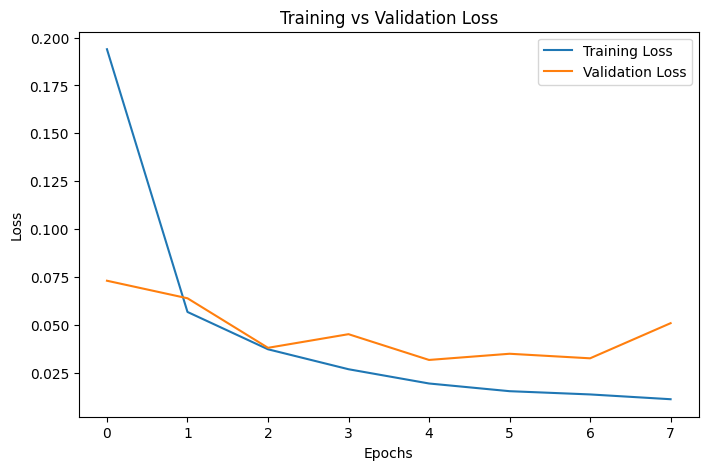

In [9]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [10]:
val_loss, val_accuracy = model.evaluate(X, y, verbose=0)
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.996404767036438


In [11]:
test_predictions = model.predict(X_test)
predicted_labels = np.argmax(test_predictions, axis=1)

print(predicted_labels[:10])

875/875 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step
[2 0 9 0 3 7 0 3 0 3]


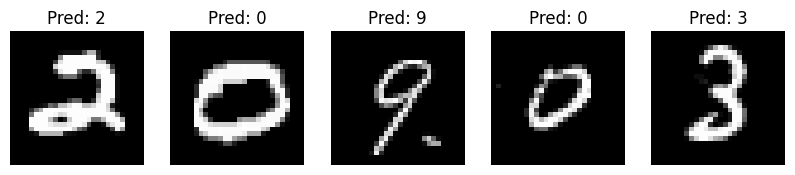

In [12]:
plt.figure(figsize=(10,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray', interpolation='nearest')
    plt.title(f"Pred: {predicted_labels[i]}")
    plt.axis('off')

plt.show()

In [14]:
model.save("cnn_digit_model.h5")